In [36]:
import math
from collections import Counter
import matplotlib.pyplot as plt

def get_column_read_order(key: str) -> list[int]:
    sorted_pairs = sorted(enumerate(key), key=lambda x: x[1])
    return [original_idx for original_idx, _ in sorted_pairs]

In [37]:
# === DATA ===
KEY = "PROJEV"

PLAINTEXT = (
    "RUSKYPREZIDENTVLADIMIRPUTINPRONESLVECTVRTEKTRADICNIPROJEVOSTAVUFEDERACE"
    "VENOVALSETOMUZERUSKOMUSIPOKRACOVATVTRANSFORMACIANEMUZESESPOKOJITSESOUCAS"
    "NYMSTAVEMZMINILSTOUPAJICIPOCETCHUDYCHIZAOSTALOUINFRASTRUKTURUNUTNOUPODPORU"
    "DUCHODCUMIMLADYMRODINYMABYSEZVRYTILNEPRIZNIVYDEMOGRAFICKYVYVOJ"
)

# Referenční šifrové texty ze zadání
REF_CT_COLUMNAR_V1 = (
    "YDAPRVTDRSEEAMSICTOAEKESAIOCTCSITROOHIMYEIIDAVKILRPLRAPOFCVOUSAVFIZOSATM"
    "TIEYOUSUNPCMYNSTRYRYSZVINSVRIVUAOTRURTSCUPTCSZSJCDAOATTDUUDIYYPVGKJRRNIT"
    "NCKCJAEESZOOVAMEEJOYEIPPHIAFUNPUDLOAVNNMIVUETMIETTNEVRNEEMKANAMSIUMMLAOU"
    "ZLRKUODCADBREIOCOPEDUOEEIOTDVLUKPORRNSOSNVNUICHTNRUUROMRMZLZEFY"
)

REF_CT_COLUMNAR_V2 = (
    "KILRPLRAPOFCVOUSAVFIZOSATMTIEYOUSUNPCMYNSTRYRYYDAPRVTDRSEEAMSICTOAEKESAI"
    "OCTCSITROOHIMYEIIDAVSZVINSVRIVUAOTRURTSCUPTCSZSJCDAOATTDUUDIYYPVGKJUETMI"
    "ETTNEVRNEEMKANAMSIUMMLAOUZLRKUODCADBREIOCORRNITNCKCJAEESZOOVAMEEJOYEIPPHI"
    "AFUNPUDLOAVNNMIVPEDUOEEIOTDVLUKPORRNSOSNVNUICHTNRUUROMRMZLZEFY"
)

REF_CT_ROW = (
    "YKSRUPDIZREEALVNTDPRIIMURPNTIOVLSNEETRVCTEDARKTIRPICNOSOVJETEFUAVDECAERVA"
    "VOENLMOTSEUSURZEKISUOMPCAROKOTVTVAROFSANRAICMANEZUEMSKOPESOESJISSACOUNATSY"
    "MVIMZEMNOTSILUCIJPAITECPOCCYDHUHSOAIZTIUOALNTSAFRRRUTUKUONTNUUOPDPORHCUUDO"
    "IMUDCMMYDLARYNIODMESYABZITYVRLIRPNEZDYVNIEARGMOFVYKICYJVO"
)

In [ ]:
def columnar_encrypt(plaintext: str, key: str) -> str:
    plaintext = plaintext.upper().replace(" ", "")
    num_cols = len(key)
    num_rows = math.ceil(len(plaintext) / num_cols)
    
    col_read_order = get_column_read_order(key)
    
    # Přečteme sloupce v pořadí klíče
    ciphertext = ""
    for col in col_read_order:
        for row in range(num_rows):
            idx = row * num_cols + col
            if idx < len(plaintext):
                ciphertext += plaintext[idx]
    
    return ciphertext


def columnar_decrypt(ciphertext: str, key: str) -> str:
    ciphertext = ciphertext.upper().replace(" ", "")
    num_cols = len(key)
    num_rows = math.ceil(len(ciphertext) / num_cols)
    remainder = len(ciphertext) % num_cols  # Počet sloupců s plným počtem řádků
    
    col_read_order = get_column_read_order(key)
    
    col_lengths = []
    for col in range(num_cols):
        if remainder == 0:
            col_lengths.append(num_rows)
        elif col < remainder:
            col_lengths.append(num_rows)
        else:
            col_lengths.append(num_rows - 1)
    
    columns = [""] * num_cols
    pos = 0
    for col in col_read_order:
        length = col_lengths[col]
        columns[col] = ciphertext[pos:pos + length]
        pos += length
    
    # Čteme po řádcích
    plaintext = ""
    for row in range(num_rows):
        for col in range(num_cols):
            if row < len(columns[col]):
                plaintext += columns[col][row]
    
    return plaintext

ct_encrypted = columnar_encrypt(PLAINTEXT, KEY)
print(f"Šifrový text (délka {len(ct_encrypted)}):")
print(ct_encrypted)
print()

ct_decrypted = columnar_decrypt(ct_encrypted, KEY)
print(f"Dešifrovaný text (délka {len(ct_decrypted)}):")
print(ct_decrypted)


Šifrový text (délka 279):
YDAPRVTDRSEEAMSICTOAEKESAIOCTCSITROOHIMYEIIDAVKILRPLRAPOFCVOUSAVFIZOSATMTIEYOUSUNPCMYNSTRYRYSZVINSVRIVUAOTRURTSCUPTCSZSJCDAOATTDUUDIYYPVGKJRRNITNCKCJAEESZOOVAMEEJOYEIPPHIAFUNPUDLOAVNNMIVUETMIETTNEVRNEEMKANAMSIUMMLAOUZLRKUODCADBREIOCOPEDUOEEIOTDVLUKPORRNSOSNVNUICHTNRUUROMRMZLZEFY

Dešifrovaný text (délka 279):
RUSKYPREZIDENTVLADIMIRPUTINPRONESLVECTVRTEKTRADICNIPROJEVOSTAVUFEDERACEVENOVALSETOMUZERUSKOMUSIPOKRACOVATVTRANSFORMACIANEMUZESESPOKOJITSESOUCASNYMSTAVEMZMINILSTOUPAJICIPOCETCHUDYCHIZAOSTALOUINFRASTRUKTURUNUTNOUPODPORUDUCHODCUMIMLADYMRODINYMABYSEZVRYTILNEPRIZNIVYDEMOGRAFICKYVYVOJ


In [ ]:
def row_encrypt(plaintext: str, key: str) -> str:
    plaintext = plaintext.upper().replace(" ", "")
    num_cols = len(key)
    num_rows = math.ceil(len(plaintext) / num_cols)
    
    ciphertext = ""
    for row in range(num_rows):
        row_chars = []
        for col in range(num_cols):
            idx = row * num_cols + col
            if idx < len(plaintext):
                row_chars.append(plaintext[idx])
            else:
                row_chars.append("")  # Neúplný poslední řádek
        
        # Čteme v pořadí daném rankem
        col_read_order = get_column_read_order(key)
        for col in col_read_order:
            if row_chars[col]:
                ciphertext += row_chars[col]
    
    return ciphertext


def row_decrypt(ciphertext: str, key: str) -> str:
    ciphertext = ciphertext.upper().replace(" ", "")
    num_cols = len(key)
    num_rows = math.ceil(len(ciphertext) / num_cols)
    remainder = len(ciphertext) % num_cols
    col_read_order = get_column_read_order(key)
    
    plaintext = ""
    pos = 0
    for row in range(num_rows):
        is_last_partial = (row == num_rows - 1 and remainder > 0)
        original_row = [""] * num_cols
        
        # Přeskočíme neúplné sloupce
        for col in col_read_order:
            if is_last_partial and col >= remainder:
                continue
            original_row[col] = ciphertext[pos]
            pos += 1
        
        plaintext += "".join(original_row)
    
    return plaintext


rt_encrypted = row_encrypt(PLAINTEXT, KEY)
print(f"Šifrový text (délka {len(rt_encrypted)}):")
print(rt_encrypted)
print()

rt_decrypted = row_decrypt(rt_encrypted, KEY)
print(f"Dešifrovaný text (délka {len(rt_decrypted)}):")
print(rt_decrypted)

Šifrový text (délka 279):
YKSRUPDIZREEALVNTDPRIIMURPNTIOVLSNEETRVCTEDARKTIRPICNOSOVJETEFUAVDECAERVAVOENLMOTSEUSURZEKISUOMPCAROKOTVTVAROFSANRAICMANEZUEMSKOPESOESTJISSACOUNATSYMVIMZEMNOTSILUCIJPAITECPOCCYDHUHSOAIZTIUOALNTSAFRRRUTUKUONTNUUOPDPORHCUUDOIMUDCMMYDLARYNIODMESYABZITYVRLIRPNEZDYVNIEARGMOFVYKICYJVO

Dešifrovaný text (délka 279):
RUSKYPREZIDENTVLADIMIRPUTINPRONESLVECTVRTEKTRADICNIPROJEVOSTAVUFEDERACEVENOVALSETOMUZERUSKOMUSIPOKRACOVATVTRANSFORMACIANEMUZESESPOKOJITSESOUCASNYMSTAVEMZMINILSTOUPAJICIPOCETCHUDYCHIZAOSTALOUINFRASTRUKTURUNUTNOUPODPORUDUCHODCUMIMLADYMRODINYMABYSEZVRYTILNEPRIZNIVYDEMOGRAFICKYVYVOJ


Délka M1: 216
Index koincidence M1: 0.048665


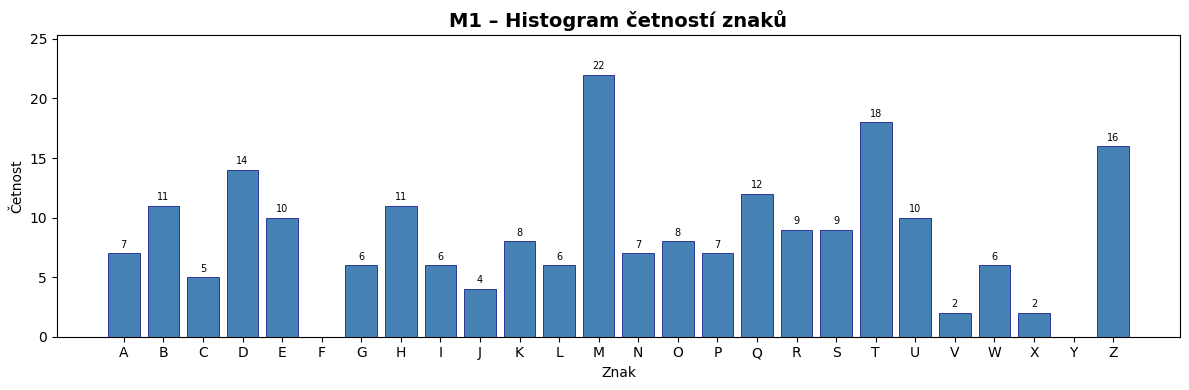

Délka M2: 279
Index koincidence M2: 0.053609


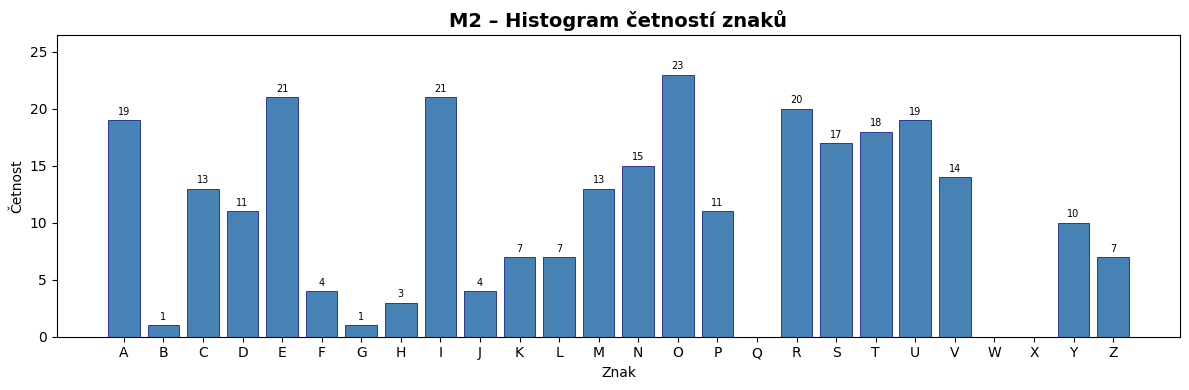

In [ ]:
M1 = (
    "RTGNDKZEZBQPKMBOBIEIBBHRSSQMOZAZZBUMJWZCHDZARTQDTRUCHKTDUWGDMMOHRMLASIT"
    "NDDQTRQZUTHQMHHMSZPZECMETMITOQIOHZVMSDDQRNDKCGWPEUMHSDKTPNTAHZKTSMQTO"
    "UQWEMLGBTLQPNTAJZAZOSMBLNBKVMWOIJTQSMWGPNLZUKCBRDAPEMJGDDUMXHUMLMMEER"
    "BETTXZU"
)

M2 = (
    "YDAPRVTDRSEEAMSICTOAEKESAIOCTCSITROOHIMYEIIDAVKILRPLRAPOFCVOUSAVFIZOSATM"
    "TIEYOUSUNPCMYNSTRYRYSZVINSVRIVUAOTRURTSCUPTCSZSJCDAOATTDUUDIYYPVGKJRRNIT"
    "NCKCJAEESZOOVAMEEJOYEIPPHIAFUNPUDLOAVNNMIVUETMIETTNEVRNEEMKANAMSIUMMLAOU"
    "ZLRKUODCADBREIOCOPEDUOEEIOTDVLUKPORRNSOSNVNUICHTNRUUROMRMZLZEFY"
)


def char_frequency(text: str) -> dict[str, int]:
    text = text.upper()
    freq = {}
    for ch in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
        count = text.count(ch)
        if count > 0:
            freq[ch] = count
    return freq


def index_of_coincidence(text: str) -> float:
    text = text.upper()
    n = len(text)
    if n <= 1:
        return 0.0
    freq = Counter(text)
    ic = sum(f * (f - 1) for f in freq.values()) / (n * (n - 1))
    return ic


def plot_histogram(text: str, title: str):
    alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    freq = {ch: text.upper().count(ch) for ch in alphabet}
    
    fig, ax = plt.subplots(figsize=(12, 4))
    colors = ['steelblue' if freq[ch] > 0 else 'lightgray' for ch in alphabet]
    bars = ax.bar(list(alphabet), [freq[ch] for ch in alphabet], color=colors, edgecolor='navy', linewidth=0.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Znak")
    ax.set_ylabel("Četnost")
    ax.set_ylim(0, max(freq.values()) * 1.15)
    
    for bar, ch in zip(bars, alphabet):
        if freq[ch] > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(freq[ch]), ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout()
    plt.show()


print(f"Délka M1: {len(M1)}")
ic_m1 = index_of_coincidence(M1)
print(f"Index koincidence M1: {ic_m1:.6f}")

freq_m1 = char_frequency(M1)

plot_histogram(M1, "M1 – Histogram četností znaků")

print(f"Délka M2: {len(M2)}")
ic_m2 = index_of_coincidence(M2)
print(f"Index koincidence M2: {ic_m2:.6f}")

freq_m2 = char_frequency(M2)

plot_histogram(M2, "M2 – Histogram četností znaků")